In [1]:
import time
from IPython.core.display import Markdown
from dotenv import load_dotenv
from langchain_community.chat_models import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph
from src.States import *
from typing import *
import random
from langgraph.constants import START,END
import copy
from PIL import Image, ImageDraw, ImageFont
import io
from IPython.display import Image as IPImage, display

load_dotenv()

C:\Users\harsi\PycharmProjects\PythonLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
sysmessage = SystemMessage(f"You are an AI agent that is being used for simulating AI F1 cars to a extent, your job is to be as a Race Engineer, you should also take into consideration about the lap times you can create, Take your current position into account. You can try for undercut. Lap time is determined by laptime = generatelaptime + (TyreDegradation/100)*2 + if gap less than 1 random.random() + (fuelrem/totalfuel)*2, think what the other cars might do and TyreDegradation of 100 means puncture and time is +20seconds. You need to choose wet when weather is wet")

LaptimeModel = ChatOpenAI(model="gpt-4.1-nano-2025-04-14",temperature=0)
laptime_sysmessage=SystemMessage("You are a laptime generating AI agent that uses the car's telemetry data and trackdata to find the approx laptime in seconds that is in the range of 1 second up or down and give only the value in seconds and have a precision of 3 digits in the milliseconds.")


C:\Users\harsi\AppData\Local\Temp\ipykernel_22200\2077558604.py:3: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the `langchain-openai package and should be used instead. To use it run `pip install -U `langchain-openai` and import as `from `langchain_openai import ChatOpenAI``.
  LaptimeModel = ChatOpenAI(model="gpt-4.1-nano-2025-04-14",temperature=0)


In [3]:
MOCK_TRACK_DATA: List[TrackData] = [
    {
        "TrackID": 1,
        "TrackName": "Monaco",

        "Soft_Deg": 8.1,
        "Medium_Deg": 6.67,
        "Hard_Deg": 5.1,
        "Wet_Deg": 7.1,

        "Soft_Lap": 113.5,
        "Medium_Lap": 115.5,
        "Hard_Lap": 117.5,
        "Wet_Lap": 137.5,

        "PitLoss": 19.3,
        "FuelLoss": 2.3,
        "TotalFuel": 69,
    },
    {
        "TrackID": 2,
        "TrackName": "Great Britain",
        "Soft_Deg": 10.25,
        "Medium_Deg": 9.1,
        "Hard_Deg": 7.8,
        "Wet_Deg": 9.5,
        "Soft_Lap": 146.5,
        "Medium_Lap": 149.5,
        "Hard_Lap": 151.5,
        "Wet_Lap": 164.5,
        "PitLoss": 20.2,
        "FuelLoss": 3.4,
        "TotalFuel": 102,
    },
    {
        "TrackID": 3,
        "TrackName": "Abu Dhabi",
        "Soft_Deg": 10.25,
        "Medium_Deg": 8.25,
        "Hard_Deg": 6.75,
        "Wet_Deg": 7.1,
        "Soft_Lap": 145.5,
        "Medium_Lap": 148.5,
        "Hard_Lap": 150.5,
        "Wet_Lap": 162.5,
        "PitLoss": 21.7,
        "FuelLoss": 3.7,
        "TotalFuel": 111,
    },
]

MOCK_CAR_LIST: List[Car] = [
    {
        "CarPosition": 1,
        "CarID": 4,
        "Team": "McLaren",
        "Telemetry": None,
        "Driver": "Lando Norris",
        "TotalRaceTime": 0.0,
        "SpeedDelta":-0.05,
        "isUser": False,
    },
    {
        "CarPosition": 2,
        "CarID": 1,
        "Team": "RedBull",
        "Telemetry": None,
        "Driver": "Max Verstappen",
        "TotalRaceTime": 0,
        "SpeedDelta":-0.08,
        "isUser": False,
    },
    {
        "CarPosition": 3,
        "CarID": 63,
        "Team": "Mercedes",
        "Telemetry": None,
        "Driver": "George Russell",
        "TotalRaceTime": 0.0,
        "SpeedDelta":0.08,
        "isUser": False,
    },
    {
        "CarPosition": 4,
        "CarID": 81,
        "Team": "McLaren",
        "Telemetry": None,
        "Driver": "Oscar Piastri",
        "TotalRaceTime": 0.0,
        "SpeedDelta":-0.05,
        "isUser": False,
    },
    {
        "CarPosition": 5,
        "CarID": 12,
        "Team": "Mercedes",
        "Telemetry": None,
        "Driver": "Kimi Antonelli",
        "TotalRaceTime": 0.08,
        "SpeedDelta":0.08,
        "isUser": False,
    },
    {
        "CarPosition": 6,
        "CarID": 22,
        "Team": "RedBull",
        "Telemetry": None,
        "Driver": "Yuki Tsunoda",
        "TotalRaceTime": 0.0,
        "SpeedDelta":0.1,
        "isUser": False,
    },
    {
        "CarPosition": 7,
        "CarID": 16,
        "Team": "Ferrari",
        "Telemetry": None,
        "Driver": "Charles Leclerc",
        "TotalRaceTime": 0.0,
        "SpeedDelta":0.22,
        "isUser": False,
    },
    {
        "CarPosition": 8,
        "CarID": 44,
        "Team": "Ferrari",
        "Telemetry": None,
        "Driver": "Lewis Hamilton",
        "TotalRaceTime": 0.0,
        "SpeedDelta":0.22,
        "isUser": False,
    },
    {
        "CarPosition": 9,
        "CarID": 14,
        "Team": "Aston Martin",
        "Telemetry": None,
        "Driver": "Fernando Alonso",
        "TotalRaceTime": 0,
        "SpeedDelta":0.53,
        "isUser": False,
    },
    {
        "CarPosition": 10,
        "CarID": 18,
        "Team": "Aston Martin",
        "Telemetry": None,
        "Driver": "Lance Stroll",
        "TotalRaceTime": 0,
        "SpeedDelta":0.53,
        "isUser": False,
    },
    {
        "CarPosition": 11,
        "CarID": 87,
        "Team": "Haas",
        "Telemetry": None,
        "Driver": "Oliver Bearman",
        "TotalRaceTime": 0,
        "SpeedDelta":0.42,
        "isUser": False,
    },
    {
        "CarPosition": 12,
        "CarID": 31,
        "Team": "Haas",
        "Telemetry": None,
        "Driver": "Esteban Ocon",
        "TotalRaceTime": 0,
        "SpeedDelta":0.42,
        "isUser": False,
    },
    {
        "CarPosition": 13,
        "CarID": 23,
        "Team": "Williams",
        "Telemetry": None,
        "Driver": "Alex Albon",
        "TotalRaceTime": 0,
        "SpeedDelta":0.82,
        "isUser": False,
    },
    {
        "CarPosition": 14,
        "CarID": 55,
        "Team": "Williams",
        "Telemetry": None,
        "Driver": "Carlos Sainz",
        "TotalRaceTime": 0,
        "SpeedDelta":0.82,
        "isUser": False,
    },
]

In [4]:
def select_track(state: GlobalState) -> dict:
    """This tool is used to select the user track and define it in all the global"""
    selection = int(input("Select Track: \n1. Monaco\n2. Great Britain\n3. Abu Dhabi\n"))
    while selection not in [1,2,3]:
        selection = int(input("Pls Select a Valid Track\nSelect Track: \n1. Monaco\n2. Great Britain\n3. Abu Dhabi\n"))

    Markdown(f"Selected Track: {selection}")

    return {"Track" : MOCK_TRACK_DATA[selection-1]}

def random_weather(state: GlobalState) -> dict:
    """This tool is used to randomly select a weather station and define it in all the global"""
    bias = [0.2,0.8]
    weather = random.choices(["Wet","Dry"],weights=bias,k=1)[0]

    Markdown(f"Weather Generated: {weather}")

    return {"Weather" : weather}

def create_cars(state: GlobalState) -> dict:
    """This tool is used to create cars and assign a car based on the input"""


    cars = copy.deepcopy(MOCK_CAR_LIST)
    # -----------------------
    for i in range(len(cars)):
        print(f"Car #{i+1:^4}: {cars[i]['Driver']:^20} - {cars[i]['Team']:^10}")
    time.sleep(5)
    selection = int(input(
        """--- Select a Driver ---\nEnter the position number of the driver: """))
    while selection not in range(1,len(MOCK_CAR_LIST)+1):
        selection = int(input(
        """--- Select a Driver ---\nEnter the position number of the driver: """))

    Markdown(f"😊😊 Selected Driver: {selection} 😊😊")


    cars[selection-1]["isUser"] = True

    return {"Cars": cars,"UserCar": cars[selection-1]}

In [5]:
def race_briefing(state: GlobalState) -> dict:
    """This node summarizes the race setup."""
    print("\n==========================================")
    print("           🏁 RACE BRIEFING 🏁            ")
    print("==========================================")


    track = state['Track']
    print(f"TRACK: {track['TrackName']}")
    print(f"   - Soft Deg: {track['Soft_Deg']}per lap | Lap Time: {track['Soft_Lap']}s")
    print(f"   - Med  Deg: {track['Medium_Deg']}per lap | Lap Time: {track['Medium_Lap']}s")
    print(f"   - Hard Deg: {track['Hard_Deg']}per lap | Lap Time: {track['Hard_Lap']}s")
    print(f"   - Wet  Deg: {track['Wet_Deg']}per lap  | Lap Time: {track['Wet_Lap']}s")
    print(f"   - Pit Loss: {track['PitLoss']}s")


    print(f"\n☁️ WEATHER: {state['Weather']}")

    user_car = state['UserCar']
    print(f"\n🏎️ YOUR CAR: {user_car['Driver']} ({user_car['Team']})")

    return {}

def select_tyre(State: GlobalState) -> dict:
    """This tool is used to select a tyre based on the input for the user car"""
    selection = int(input(f"Select a tyre for your car\n "
                          f"Track: {State['Track']['TrackName']}\nWeather: {State["Weather"]}\n\t 1. Soft (deg: {State['Track']['Soft_Deg']})\n\t 2. Medium (deg: {State['Track']['Medium_Deg']})\n\t 3. Hard (deg: {State['Track']['Hard_Deg']})\n\t 4. Wet (deg: {State["Track"]["Wet_Deg"]})"))
    while selection not in [1,2,3,4]:
        selection = int(input(f"Select a tyre for your car\n "
                          f"Track: {State['Track']['TrackName']}\nWeather: {State["Weather"]}\n\t 1. Soft (deg: {State['Track']['Soft_Deg']})\n\t 2. Medium (deg: {State['Track']['Medium_Deg']})\n\t 3. Hard (deg: {State['Track']['Hard_Deg']})\n\t 4. Wet (deg: {State["Track"]["Wet_Deg"]})"))

    car = State['UserCar']

    initial_telemetry : TypedDict[TelemetryData] = {
        "Tyre": "Soft",
        "TyreLaps": 0,
        "TyreDegradation": 0,
        "laps_remaining": State['TotalLaps'],
        "LastLapTime": 0.0,
        "FuelRemaining": State['Track']['TotalFuel'],
    }

    if selection == 1:
        initial_telemetry["Tyre"] = "Soft"
    elif selection == 2:
        initial_telemetry["Tyre"] = "Medium"
    elif selection == 3:
        initial_telemetry["Tyre"] = "Hard"
    else:
        initial_telemetry["Tyre"] = "Wet"

    car['Telemetry'] = initial_telemetry

    return {"UserCar": car}

def generate_telemetry(State: GlobalState) -> dict:
    """This tool is used to generate telemetry for the AI controlled cars"""


    cars = State['Cars']
    for car in cars:
        if not car['isUser']:
            model = ChatOpenAI(model="gpt-4.1-nano-2025-04-14",temperature=0)
            initial_telemetry : TypedDict[TelemetryData] = {
                "Tyre": None,
                "TyreLaps": 0,
                "TyreDegradation": 0,
                "laps_remaining": State['TotalLaps'],
                "LastLapTime": 0.0,
                "FuelRemaining": State['Track']['TotalFuel'],
            }
            car['Telemetry'] = initial_telemetry

            input_messages = [sysmessage,HumanMessage(f"{State['Track']} and {State['Weather']} and {initial_telemetry}, the tyre deg is amt per lap so based on this data choose a tyre that will be suitable for your car. Give the answer as Soft, Medium, Hard or Wet for your car in one word and no explaination. you need to use 2 different tyre compounds")]
            res = model.invoke(input_messages)
            #print(res)
            car['Telemetry']["Tyre"] = res.content

    return {"Cars": cars}

def generate_grid(State: GlobalState) -> dict:
    """This tool is used to generate grid of telemetry for the cars"""
    cars = State['Cars']

    cars1 = cars[0:5]
    random.shuffle(cars1)
    cars2 = cars[5:10]
    random.shuffle(cars2)
    cars3 = cars[10:14]
    random.shuffle(cars3)
    cars = cars1 + cars2 + cars3


    for i in range(14):
        cars[i]['CarPosition'] = i+1
        cars[i]['TotalRaceTime'] = 0.25 * i


    return {"Cars": cars}

def print_grid(State: GlobalState) -> dict:
    """This tool is used to Print the grid of the cars"""
    print("\n==========================================")
    print("           🏁 RACE GRID 🏁            ")
    print("==========================================")

    i=0
    for car in State['Cars']:
        if i % 2 == 0:
            print(f" ____________________ ")
            print(f"|                    |")
            print(f"| {car['CarID']:^19}|")
            print(f"| {car['Driver']:^19}|")

        else:
            print(f"\t\t\t\t\t\t ____________________ ")
            print(f"\t\t\t\t\t\t|                    |")
            print(f"\t\t\t\t\t\t| {car['CarID']:^19}|")
            print(f"\t\t\t\t\t\t| {car['Driver']:^19}|")
        i+=1

In [6]:
def sort_cars(cars: List[Car]) -> List[Car]:
    """This function is used to sort the cars according to the position"""

    for i in range(0,len(cars)-1):
        for j in range(i+1,len(cars)):
            if cars[i]['TotalRaceTime'] > cars[j]['TotalRaceTime']:
                temp = cars[i]
                cars[i] = cars[j]
                cars[j] = temp

    i=1
    for car in cars:
        car['CarPosition']=i
        i+=1

    return cars

def generate_timing_sheet(State: GlobalState) -> dict:
    """This is used to generate timing sheet for the cars"""
    cars = State['Cars']
    cars = sort_cars(cars)

    print("\n==========================================")
    print(f"       🏁 TIMING SHEET - Lap-{State['CurrentLap']} 🏁        ")
    print("==========================================")

    print(f"{"Position":^10} {"Driver Name":^20} - {"Gap"}")
    print(f"{cars[0]['CarPosition']:^10} {cars[0]['Driver']:^20} - 0")
    for i in range(1,len(cars)):
        temp = round(cars[i]['TotalRaceTime'] - cars[i-1]['TotalRaceTime'],3)
        print(f"{cars[i]['CarPosition']:^10} {cars[i]['Driver']:^20} - {temp}")

    return {'Cars': cars}

def generate_laptime(State: GlobalState) -> dict:
    """This tool is used to generate laptime for the cars"""
    cars = State['Cars']

    for i in range(0,len(cars)):
        input_messages = [laptime_sysmessage, HumanMessage(f"Use this data {cars[i]['Telemetry']} and {State['Track']} and generate the laptime for your car, see for the tyre used and generate based on that. Generate and give me back only the seconds,millis and nothing else.")]
        res = LaptimeModel.invoke(input_messages)
        #print(res)
        race_time = float(res.content)
        race_time += round(((cars[i]['Telemetry']['TyreDegradation']/100)*2),3) + round(((
                    cars[i]['Telemetry']['FuelRemaining'] / State['Track']['TotalFuel'])*2),3) + cars[i]['SpeedDelta']*2

        if i!=0 and cars[i]['TotalRaceTime']-cars[i - 1]['TotalRaceTime']<1:
            race_time-=round(random.random(),3)
        if i!=0 and 1 < cars[i]['TotalRaceTime'] - cars[i - 1]['TotalRaceTime'] < 3:
            race_time+=round(random.random(),3)
        if State['Weather']== "Wet" and cars[i]['Telemetry']['Tyre'] in ['Soft', 'Medium', 'Hard']:
            race_time+=30


        cars[i]['TotalRaceTime'] += round(race_time,3)
        cars[i]['Telemetry']['LastLapTime'] = round(race_time,3)


    return {'Cars': cars}

def update_telemetry(State: GlobalState) -> dict:
    """This tool is used to update telemetry for the cars"""
    cars = State['Cars']
    for car in cars:
        car['Telemetry']['TyreLaps'] += 1
        car['Telemetry']['laps_remaining'] -= 1
        car['Telemetry']['FuelRemaining'] -= State['Track']['FuelLoss']
        if car['Telemetry']['Tyre'] == "Soft":
            car['Telemetry']['TyreDegradation'] += State['Track']['Soft_Deg']
        elif car['Telemetry']['Tyre'] == "Medium":
            car['Telemetry']['TyreDegradation'] += State['Track']['Medium_Deg']
        elif car['Telemetry']['Tyre'] == "Hard":
            car['Telemetry']['TyreDegradation'] += State['Track']['Hard_Deg']
        else:
            car['Telemetry']['TyreDegradation'] += State['Track']['Wet_Deg']

    return {'Cars': cars, 'CurrentLap': State["CurrentLap"]+1}

def pitCall(State: GlobalState) -> dict:
    """This tool is used to pit the cars if needed"""

    cars = State['Cars']
    for car in cars:
        if car['isUser']:
            flag = int(input(f"{car['Telemetry']} Answer 1 if you want to pit else give 0"))
            if flag:
                selection = int(input(f"Select a tyre for your car\n "
                          f"Track: {State['Track']['TrackName']}\nWeather: {State["Weather"]}\n\t 1. Soft (deg: {State['Track']['Soft_Deg']})\n\t 2. Medium (deg: {State['Track']['Medium_Deg']})\n\t 3. Hard (deg: {State['Track']['Hard_Deg']})\n\t 4. Wet (deg: {State["Track"]["Wet_Deg"]})"))
                while selection not in [1,2,3,4]:
                    selection = int(input(f"Select a tyre for your car\n "
                          f"Track: {State['Track']['TrackName']}\nWeather: {State["Weather"]}\n\t 1. Soft (deg: {State['Track']['Soft_Deg']})\n\t 2. Medium (deg: {State['Track']['Medium_Deg']})\n\t 3. Hard (deg: {State['Track']['Hard_Deg']})\n\t 4. Wet (deg: {State["Track"]["Wet_Deg"]})"))
                if selection == 1:
                    car['Telemetry']["Tyre"] = "Soft"
                elif selection == 2:
                    car['Telemetry']["Tyre"] = "Medium"
                elif selection == 3:
                    car['Telemetry']["Tyre"] = "Hard"
                else:
                    car['Telemetry']["Tyre"] = "Wet"
                car['Telemetry']['TyreLaps'] = 0
                car['Telemetry']['TyreDegradation'] = 0
                car['Telemetry']['LastLapTime'] += State['Track']['PitLoss']
                car['TotalRaceTime'] += State['Track']['PitLoss']
        else:
            model = ChatOpenAI(model="gpt-4.1-nano-2025-04-14",temperature=0)
            flag = 0


            input_messages = [sysmessage,HumanMessage(f"{State['Track']} and {State['Weather']} and {car} and this is the other Cars and their details {cars}, the tyre deg is amt per lap so based on this data choose if you want to pit the car this lap or not. Give the answer as 0 or 1 with 0 being no and 1 being yes in one single character and no explaination")]
            res = model.invoke(input_messages)
            flag = int(res.content)
            if flag:
                input_messages.append(HumanMessage("Based on the data that you have. Give the answer as Soft, Medium, Hard or Wet for your car in one word and no explaination. you need to use 2 different tyre compounds"))
                res = model.invoke(input_messages)
                car['Telemetry']['Tyre']=res.content
                car['Telemetry']['TyreLaps'] = 0
                car['Telemetry']['TyreDegradation'] = 0
                car['Telemetry']['LastLapTime'] += State['Track']['PitLoss']
                car['TotalRaceTime'] += State['Track']['PitLoss']

    return {'Cars':cars}

def check_race_over(State: GlobalState) -> str:
    """This tool is used to check race over"""
    cars = State['Cars']
    if State['CurrentLap'] >= State['TotalLaps']:
        return 'END'
    else:
        return "CONTINUE"

def podium_celebration(State: GlobalState) -> dict:
    """Displays the Image of the Podium Celebration for the race"""

    cars = State['Cars']
    top_3 = cars[:3]


    width, height = 800, 400
    background_color = (20, 20, 20)
    img = Image.new('RGB', (width, height), color=background_color)
    draw = ImageDraw.Draw(img)

    try:

        title_font = ImageFont.truetype("arial.ttf", 30)
        text_font = ImageFont.truetype("arial.ttf", 20)
        large_font = ImageFont.truetype("arial.ttf", 40)
    except IOError:
        title_font = ImageFont.load_default()
        text_font = ImageFont.load_default()
        large_font = ImageFont.load_default()

    draw.text((width//2, 40), "GRAND PRIX PODIUM", font=title_font, fill=(255, 255, 255), anchor="mm")

    steps = [
        {"car": top_3[1], "x": 200, "y": 300, "h": 100, "color": (192, 192, 192), "rank": "2"}, # Silver
        {"car": top_3[0], "x": 400, "y": 300, "h": 150, "color": (255, 215, 0),   "rank": "1"}, # Gold
        {"car": top_3[2], "x": 600, "y": 300, "h": 80,  "color": (205, 127, 50),  "rank": "3"}  # Bronze
    ]

    for step in steps:
        car = step['car']
        x, y, h = step['x'], step['y'], step['h']

        box_width = 140
        draw.rectangle(
            [x - box_width//2, y - h, x + box_width//2, y],
            outline=(255, 255, 255), width=2, fill=background_color
        )


        draw.text((x, y - h//2), step['rank'], font=large_font, fill=step['color'], anchor="mm")


        draw.text((x, y - h - 40), car['Driver'], font=text_font, fill=(255, 255, 255), anchor="mm")
        draw.text((x, y - h - 20), car['Team'], font=text_font, fill=(150, 150, 150), anchor="mm")


        gap_str = f"+{car['TotalRaceTime'] - top_3[0]['TotalRaceTime']:.3f}s" if step['rank'] != "1" else f"{car['TotalRaceTime']:.3f}s"
        draw.text((x, y + 20), gap_str, font=text_font, fill=(200, 200, 200), anchor="mm")


    img_byte_arr = io.BytesIO()
    img.save(img_byte_arr, format='PNG')
    img_byte_arr = img_byte_arr.getvalue()


    display(IPImage(data=img_byte_arr))

    return {}


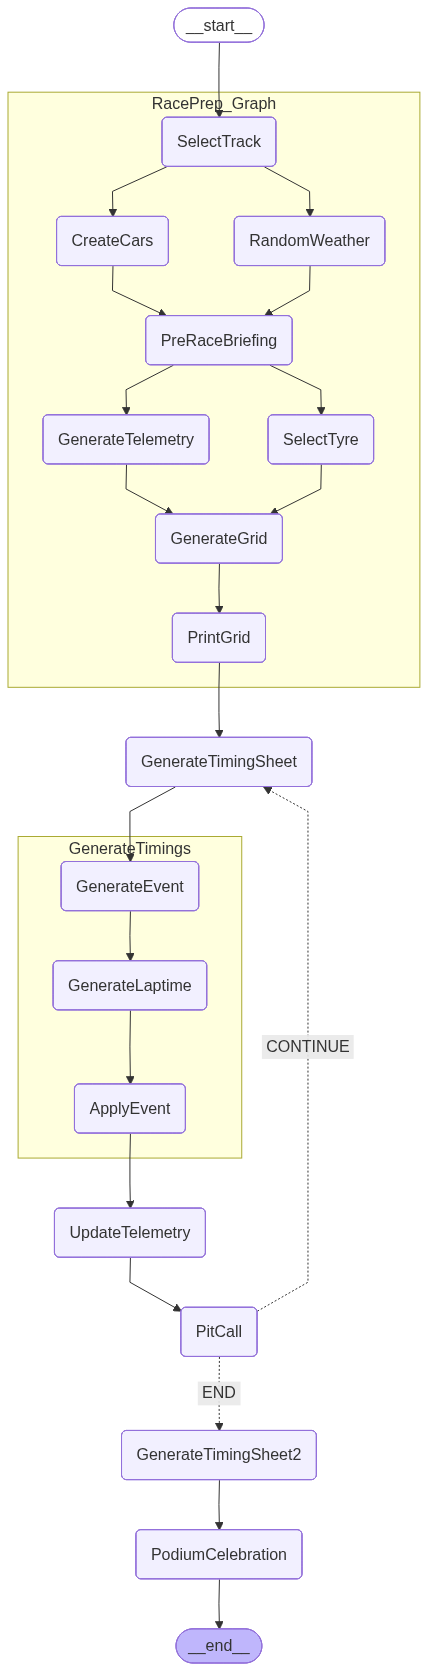

In [7]:
from src.Events import generate_race_event, apply_event_effects

main_builder=StateGraph(GlobalState)

RacePrep = StateGraph(GlobalState)

RacePrep.add_node("SelectTrack", select_track)
RacePrep.add_node("RandomWeather", random_weather)
RacePrep.add_node("CreateCars", create_cars)
RacePrep.add_node("PreRaceBriefing",race_briefing)
RacePrep.add_node("SelectTyre", select_tyre)
RacePrep.add_node("GenerateTelemetry", generate_telemetry)
RacePrep.add_node("GenerateGrid", generate_grid)
RacePrep.add_node("PrintGrid", print_grid)


RacePrep.add_edge(START,"SelectTrack")
RacePrep.add_edge("SelectTrack","RandomWeather")
RacePrep.add_edge("SelectTrack","CreateCars")
RacePrep.add_edge("RandomWeather","PreRaceBriefing")
RacePrep.add_edge("CreateCars","PreRaceBriefing")
RacePrep.add_edge("PreRaceBriefing","SelectTyre")
RacePrep.add_edge("PreRaceBriefing","GenerateTelemetry")
RacePrep.add_edge("SelectTyre","GenerateGrid")
RacePrep.add_edge("GenerateTelemetry","GenerateGrid")
RacePrep.add_edge("GenerateGrid","PrintGrid")
RacePrep.add_edge("PrintGrid",END)


RacePrep_Graph = RacePrep.compile()


Events = StateGraph(GlobalState)
Events.add_node("GenerateEvent",generate_race_event)
Events.add_node("GenerateLaptime", generate_laptime)
Events.add_node("ApplyEvent",apply_event_effects)

Events.add_edge(START,"GenerateEvent")
Events.add_edge("GenerateEvent","GenerateLaptime")
Events.add_edge("GenerateLaptime","ApplyEvent")
Events.add_edge("ApplyEvent",END)

Events_graph = Events.compile()




main_builder.add_node("RacePrep_Graph", RacePrep_Graph)
main_builder.add_node("GenerateTimingSheet", generate_timing_sheet)

main_builder.add_node("UpdateTelemetry", update_telemetry)
main_builder.add_node("GenerateTimingSheet2", generate_timing_sheet)
main_builder.add_node("GenerateTimings", Events_graph)
main_builder.add_node("PitCall",pitCall)
main_builder.add_node("PodiumCelebration",podium_celebration)

main_builder.add_edge(START,"RacePrep_Graph")
main_builder.add_edge("RacePrep_Graph","GenerateTimingSheet")
main_builder.add_edge("GenerateTimingSheet", "GenerateTimings")
main_builder.add_edge("GenerateTimings","UpdateTelemetry")
main_builder.add_edge("UpdateTelemetry","PitCall")


main_builder.add_conditional_edges("PitCall",check_race_over,
                                   {"END":"GenerateTimingSheet2",
                                    "CONTINUE":"GenerateTimingSheet"
                                    }
                                   )

main_builder.add_edge("GenerateTimingSheet2","PodiumCelebration")
main_builder.add_edge("PodiumCelebration",END)

graph = main_builder.compile()

display(IPImage(graph.get_graph(xray=1).draw_mermaid_png()))

Car # 1  :     Lando Norris     -  McLaren  
Car # 2  :    Max Verstappen    -  RedBull  
Car # 3  :    George Russell    -  Mercedes 
Car # 4  :    Oscar Piastri     -  McLaren  
Car # 5  :    Kimi Antonelli    -  Mercedes 
Car # 6  :     Yuki Tsunoda     -  RedBull  
Car # 7  :   Charles Leclerc    -  Ferrari  
Car # 8  :    Lewis Hamilton    -  Ferrari  
Car # 9  :   Fernando Alonso    - Aston Martin
Car # 10 :     Lance Stroll     - Aston Martin
Car # 11 :    Oliver Bearman    -    Haas   
Car # 12 :     Esteban Ocon     -    Haas   
Car # 13 :      Alex Albon      -  Williams 
Car # 14 :     Carlos Sainz     -  Williams 

           🏁 RACE BRIEFING 🏁            
TRACK: Great Britain
   - Soft Deg: 10.25per lap | Lap Time: 146.5s
   - Med  Deg: 9.1per lap | Lap Time: 149.5s
   - Hard Deg: 7.8per lap | Lap Time: 151.5s
   - Wet  Deg: 9.5per lap  | Lap Time: 164.5s
   - Pit Loss: 20.2s

☁️ WEATHER: Dry

🏎️ YOUR CAR: Lando Norris (McLaren)

           🏁 RACE GRID 🏁            
 ______

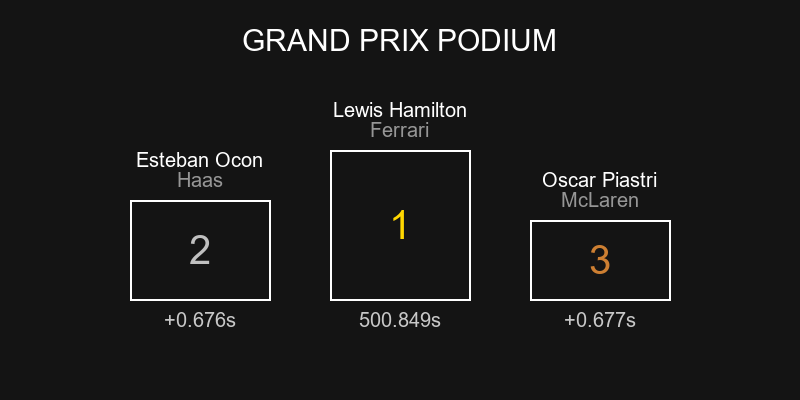

In [9]:
SampleInput = {
    "Cars": "",
    "Track": "",
    "CurrentLap": 0,
    "TotalLaps": 5,
    "RaceOver": False,
    "Event": {
            "Type": "GREEN",
            "Message": "🟢 Track Clear.",
            "AffectedCarID": None,
            "Severity": 0.0
        }
}
result = graph.invoke(SampleInput)


In [10]:
result

{'Cars': [{'CarPosition': 1,
   'CarID': 44,
   'Team': 'Ferrari',
   'Telemetry': {'Tyre': 'Medium',
    'TyreLaps': 5,
    'TyreDegradation': 45.5,
    'laps_remaining': 0,
    'LastLapTime': 151.894,
    'FuelRemaining': 84.99999999999997},
   'Driver': 'Lewis Hamilton',
   'TotalRaceTime': 500.8485,
   'SpeedDelta': 0.22,
   'isUser': False},
  {'CarPosition': 2,
   'CarID': 31,
   'Team': 'Haas',
   'Telemetry': {'Tyre': 'Medium',
    'TyreLaps': 5,
    'TyreDegradation': 45.5,
    'laps_remaining': 0,
    'LastLapTime': 151.582,
    'FuelRemaining': 84.99999999999997},
   'Driver': 'Esteban Ocon',
   'TotalRaceTime': 501.5245,
   'SpeedDelta': 0.42,
   'isUser': False},
  {'CarPosition': 3,
   'CarID': 81,
   'Team': 'McLaren',
   'Telemetry': {'Tyre': 'Medium',
    'TyreLaps': 5,
    'TyreDegradation': 45.5,
    'laps_remaining': 0,
    'LastLapTime': 151.429,
    'FuelRemaining': 84.99999999999997},
   'Driver': 'Oscar Piastri',
   'TotalRaceTime': 501.5258,
   'SpeedDelta': -0